In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [140]:
df = pd.read_csv("../data/raw/candidate_selection_dataset.csv")

In [141]:
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]=(8,5)

In [142]:
df.head()

,age,gender,education_level,experience_years,pevious_companies,distance_from_company,interview_score,skill_score,personality_score,recruitment_strategy,hiring_decision
0,26,Male,Bachelor's (Type 2),0,3,26.783828,48,78,91,Aggressive,Selected
1,39,Male,PhD,12,3,25.862694,35,68,80,Moderate,Selected
2,48,Female,Bachelor's (Type 2),3,2,9.920805,20,67,13,Moderate,Not Selected
3,34,Male,Bachelor's (Type 2),5,2,6.407751,36,27,70,Constructive,Not Selected
4,30,Female,Bachelor's (Type 1),6,1,43.105343,23,52,85,Moderate,Not Selected


In [143]:
print("No of rows : ", df.shape[0])
print("No of cols : ", df.shape[1])

No of rows :  1500
No of cols :  11


In [144]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1500 non-null   int64  
 1   gender                 1500 non-null   str    
 2   education_level        1500 non-null   str    
 3   experience_years       1500 non-null   int64  
 4   pevious_companies      1500 non-null   int64  
 5   distance_from_company  1500 non-null   float64
 6   interview_score        1500 non-null   int64  
 7   skill_score            1500 non-null   int64  
 8   personality_score      1500 non-null   int64  
 9   recruitment_strategy   1500 non-null   str    
 10  hiring_decision        1500 non-null   str    
dtypes: float64(1), int64(6), str(4)
memory usage: 188.1 KB


In [145]:
df.describe()

,age,experience_years,pevious_companies,distance_from_company,interview_score,skill_score,personality_score
count,1500.000000,1500.000000,1500.00000,1500.000000,1500.000000,1500.000000,1500.000000
mean,35.148667,7.694000,3.00200,25.505379,50.564000,51.116000,49.387333
std,9.252728,4.641414,1.41067,14.567151,28.626215,29.353563,29.353201
min,20.000000,0.000000,1.00000,1.031376,0.000000,0.000000,0.000000
25%,27.000000,4.000000,2.00000,12.838851,25.000000,25.750000,23.000000
50%,35.000000,8.000000,3.00000,25.502239,52.000000,53.000000,49.000000
75%,43.000000,12.000000,4.00000,37.737996,75.000000,76.000000,76.000000
max,50.000000,15.000000,5.00000,50.992462,100.000000,100.000000,100.000000


In [146]:
df.duplicated().sum()

np.int64(0)

In [147]:
df.isnull().sum()

age                      0
gender                   0
education_level          0
experience_years         0
pevious_companies        0
distance_from_company    0
interview_score          0
skill_score              0
personality_score        0
recruitment_strategy     0
hiring_decision          0
dtype: int64

In [148]:
df.dtypes

age                        int64
gender                       str
education_level              str
experience_years           int64
pevious_companies          int64
distance_from_company    float64
interview_score            int64
skill_score                int64
personality_score          int64
recruitment_strategy         str
hiring_decision              str
dtype: object

In [149]:
df.columns.to_list()


['age',
 'gender',
 'education_level',
 'experience_years',
 'pevious_companies',
 'distance_from_company',
 'interview_score',
 'skill_score',
 'personality_score',
 'recruitment_strategy',
 'hiring_decision']

In [150]:
categorical_column = [
    "gender",
    "education_level",
    "recruitment_strategy",
    "hiring_decision"
]

for col in categorical_column:
    print("\n", col)
    print(df[col].unique())


 gender
<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

 education_level
<ArrowStringArray>
['Bachelor's (Type 2)', 'PhD', 'Bachelor's (Type 1)', 'Master's']
Length: 4, dtype: str

 recruitment_strategy
<ArrowStringArray>
['Aggressive', 'Moderate', 'Constructive']
Length: 3, dtype: str

 hiring_decision
<ArrowStringArray>
['Selected', 'Not Selected']
Length: 2, dtype: str


In [151]:
df.hiring_decision.value_counts()

hiring_decision
Not Selected    1035
Selected         465
Name: count, dtype: int64

C:\Users\pc\AppData\Local\Temp\ipykernel_11292\387768356.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Text(0, 0.5, 'Numer of Candidates')

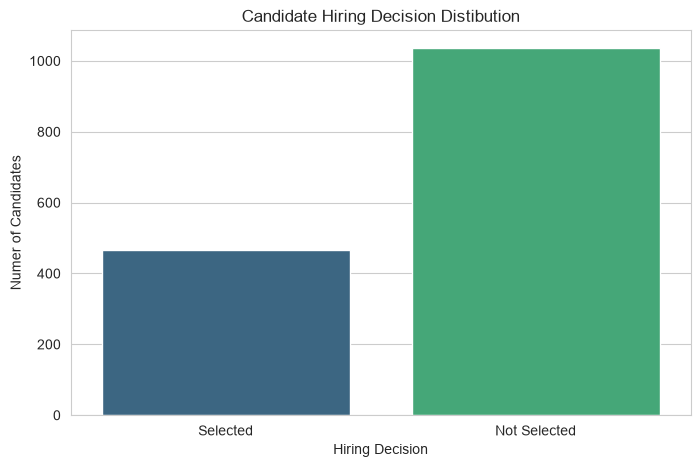

In [152]:
sns.countplot(
    data=df,
    x="hiring_decision",
    palette="viridis"
)

plt.title("Candidate Hiring Decision Distibution")
plt.xlabel("Hiring Decision")
plt.ylabel("Numer of Candidates")

Text(0.5, 0.98, 'Numerical Features Distribution')

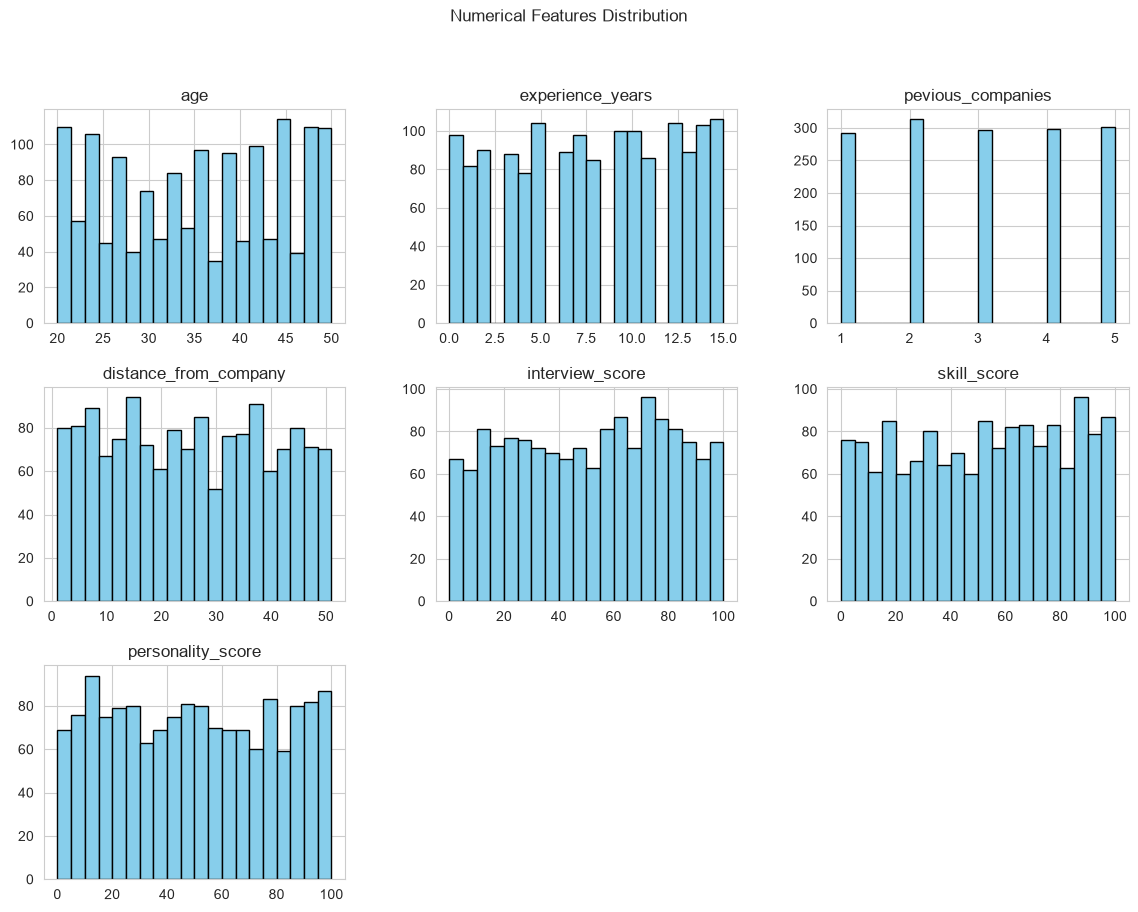

In [153]:
numerical_columns = [
    "age",
    "experience_years",
    "pevious_companies",
    "distance_from_company",
    "interview_score",
    "skill_score",
    "personality_score"
]

df[numerical_columns].hist(
    figsize=(14,10),
    bins=20,
    color="skyblue",
    edgecolor="black"
)

plt.suptitle("Numerical Features Distribution")

Text(0.5, 1.0, 'Outlier Detection in Numerical Features')

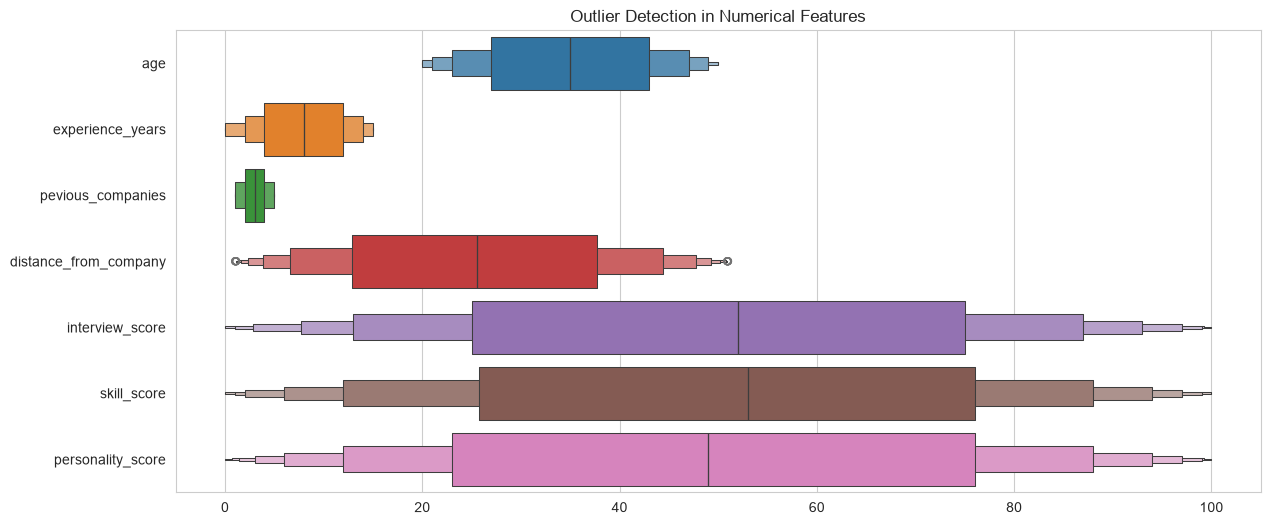

In [154]:
plt.figure(figsize=(14,6))

sns.boxenplot(
    data=df[numerical_columns],
    orient="h"
)

plt.title("Outlier Detection in Numerical Features")

C:\Users\pc\AppData\Local\Temp\ipykernel_11292\1744872097.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\pc\AppData\Local\Temp\ipykernel_11292\1744872097.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\pc\AppData\Local\Temp\ipykernel_11292\1744872097.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


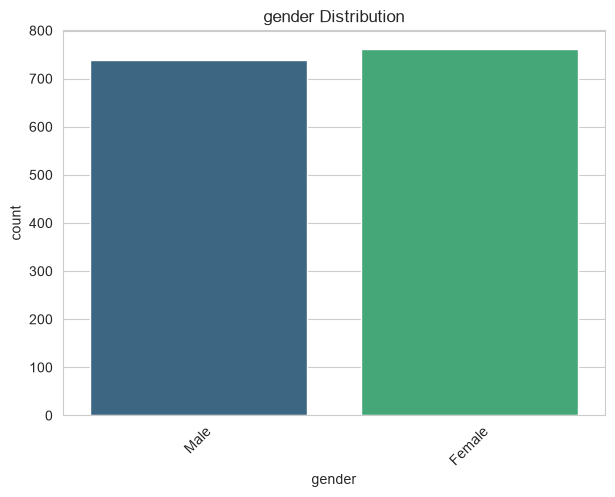

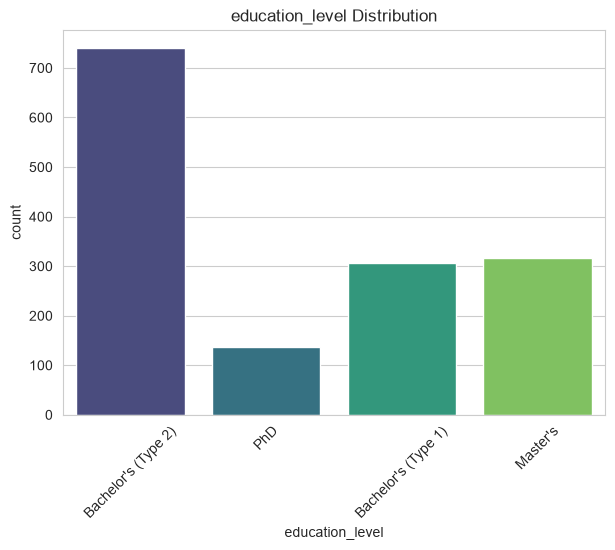

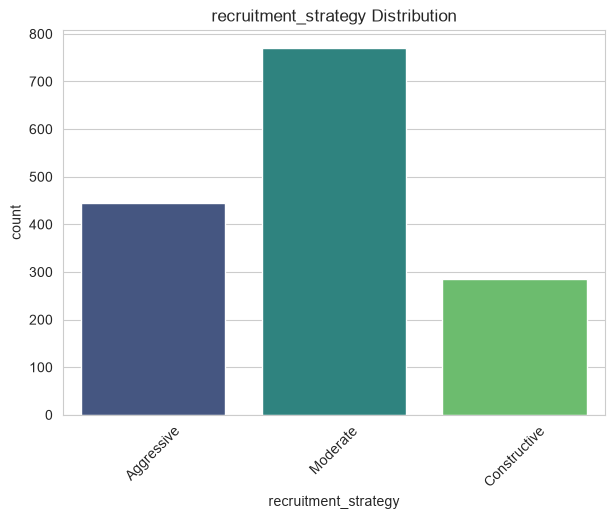

In [155]:
categorical_column = [
    "gender",
    "education_level",
    "recruitment_strategy"
]

for col in categorical_column:
    plt.figure(figsize=(7,5))

    sns.countplot(
        data=df,
        x=col,
        palette="viridis"
    )

    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.xticks(rotation=45)

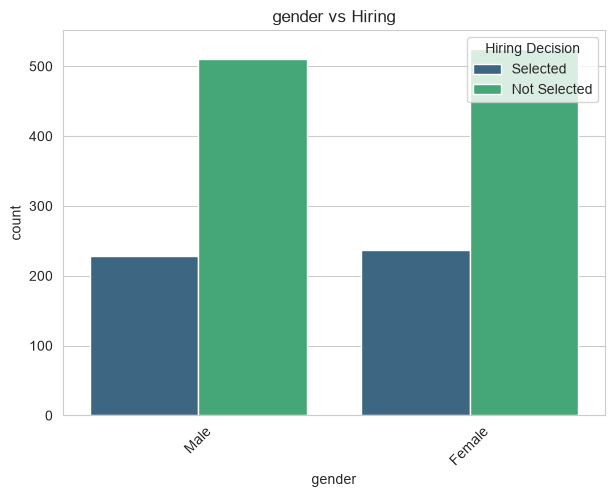

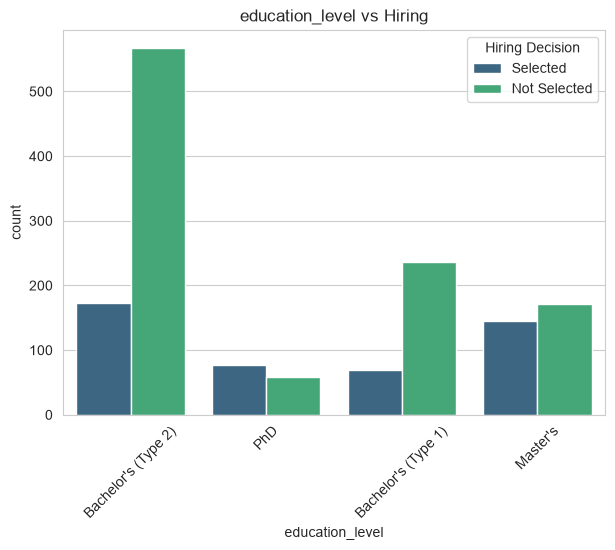

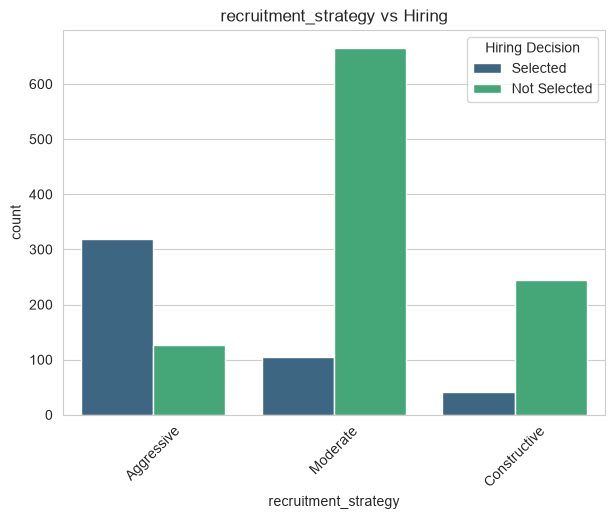

In [156]:
for col in categorical_column:
    plt.figure(figsize=(7,5))

    sns.countplot(
        data=df,
        x=col,
        hue="hiring_decision",
        palette="viridis"
    )

    plt.title(f"{col} vs Hiring")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.xticks(rotation=45)
    plt.legend(title="Hiring Decision")

In [157]:
score_columns = [
    "interview_score",
    "skill_score",
    "personality_score"
]

df.groupby("hiring_decision")[score_columns].mean()

,interview_score,skill_score,personality_score
hiring_decision,,,
Not Selected,47.762319,47.110145,46.059903
Selected,56.800000,60.032258,56.793548


In [158]:
correlation = df[numerical_columns].corr()

correlation

,age,experience_years,pevious_companies,distance_from_company,interview_score,skill_score,personality_score
age,1.000000,0.024780,-0.032580,-0.021031,-0.025579,-0.008068,0.037727
experience_years,0.024780,1.000000,0.015784,0.007920,-0.051701,0.006323,0.013891
pevious_companies,-0.032580,0.015784,1.000000,0.009187,-0.008387,0.040883,-0.024572
distance_from_company,-0.021031,0.007920,0.009187,1.000000,-0.019594,-0.016891,0.004627
interview_score,-0.025579,-0.051701,-0.008387,-0.019594,1.000000,-0.004887,-0.027967
skill_score,-0.008068,0.006323,0.040883,-0.016891,-0.004887,1.000000,-0.004266
personality_score,0.037727,0.013891,-0.024572,0.004627,-0.027967,-0.004266,1.000000


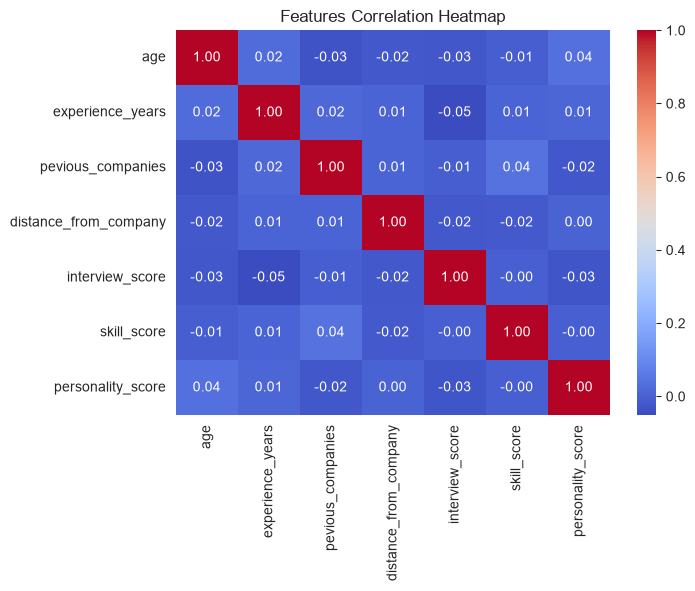

In [159]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Features Correlation Heatmap")

plt.savefig("../reports/correlation_heatmap.png",
            bbox_inches="tight",
            dpi=300)

C:\Users\pc\AppData\Local\Temp\ipykernel_11292\2127507405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


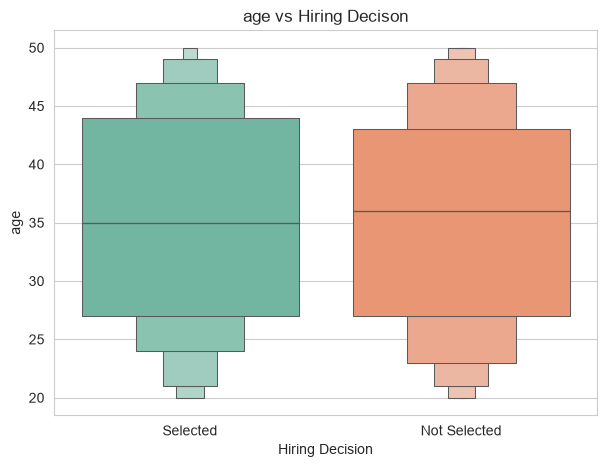

C:\Users\pc\AppData\Local\Temp\ipykernel_11292\2127507405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


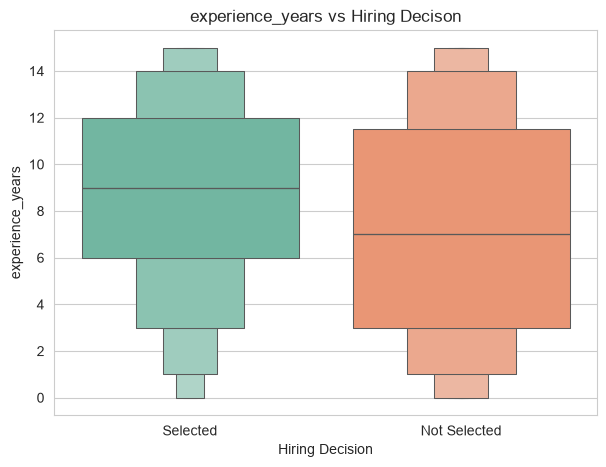

C:\Users\pc\AppData\Local\Temp\ipykernel_11292\2127507405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


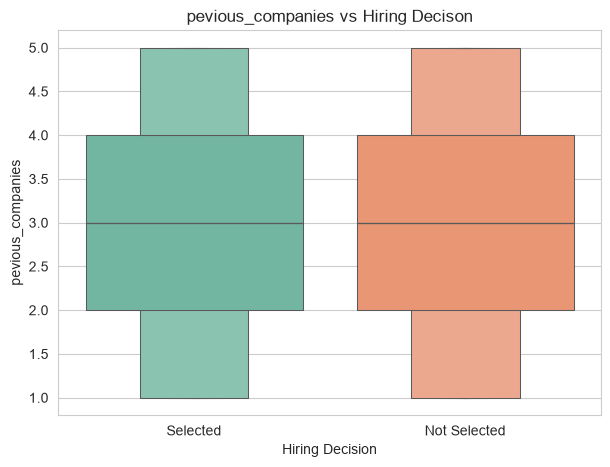

C:\Users\pc\AppData\Local\Temp\ipykernel_11292\2127507405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


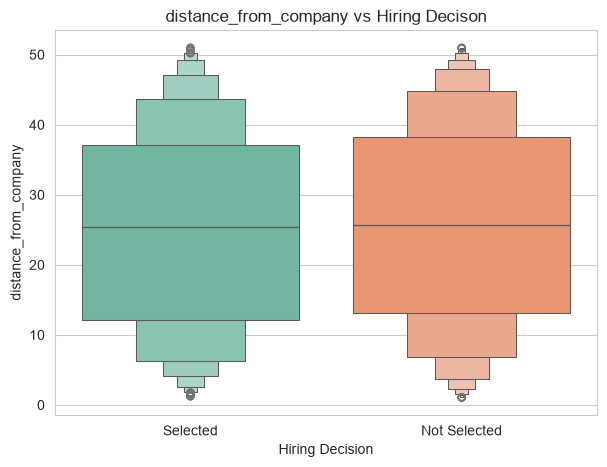

C:\Users\pc\AppData\Local\Temp\ipykernel_11292\2127507405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


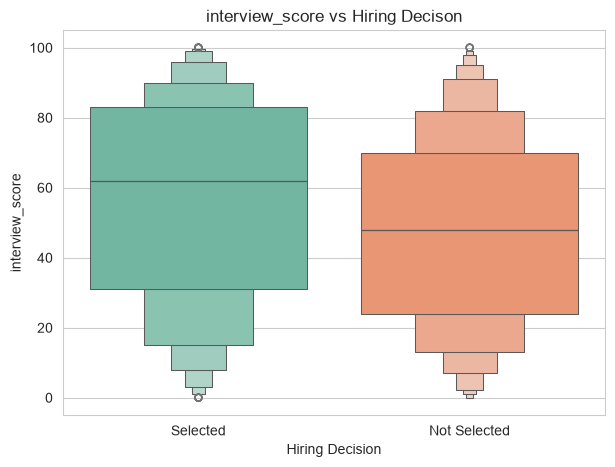

C:\Users\pc\AppData\Local\Temp\ipykernel_11292\2127507405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


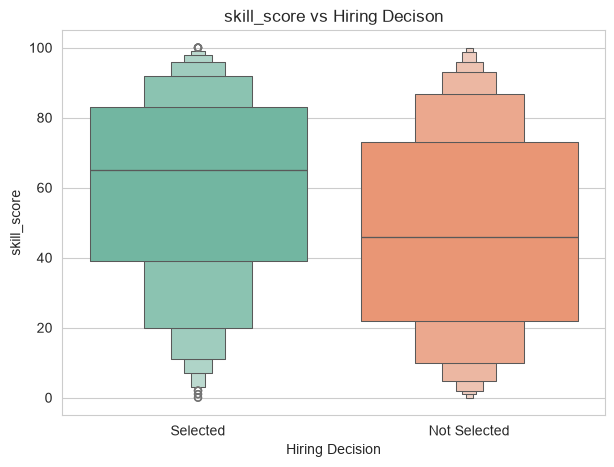

C:\Users\pc\AppData\Local\Temp\ipykernel_11292\2127507405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(


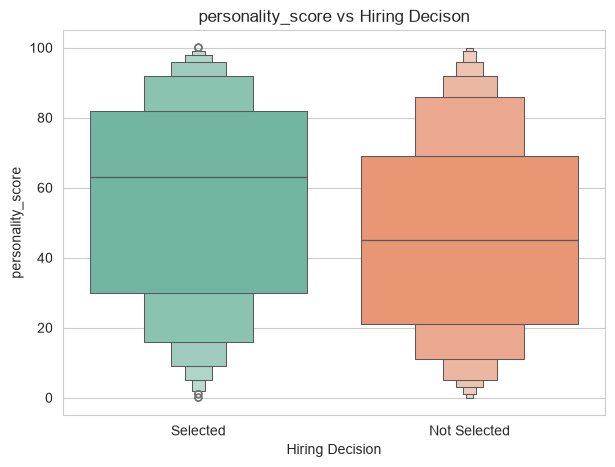

In [160]:
for col in numerical_columns:
    plt.figure(figsize=(7,5))

    sns.boxenplot(
        data=df,
        x="hiring_decision",
        y=col,
        palette="Set2"
    )

    plt.title(f"{col} vs Hiring Decison")
    plt.xlabel("Hiring Decision")
    plt.ylabel(col)
    plt.show()
    plt.close()

In [161]:
df.groupby("hiring_decision")[numerical_columns].mean()

,age,experience_years,pevious_companies,distance_from_company,interview_score,skill_score,personality_score
hiring_decision,,,,,,,
Not Selected,35.137198,7.313043,2.960386,25.669273,47.762319,47.110145,46.059903
Selected,35.174194,8.541935,3.094624,25.140583,56.800000,60.032258,56.793548


In [162]:
hiring_percentage = (
    df["hiring_decision"].value_counts(normalize=True)*100
)

hiring_percentage

hiring_decision
Not Selected    69.0
Selected        31.0
Name: proportion, dtype: float64

Preparing Features and Target

In [163]:
#features

x = df.drop("hiring_decision", axis=1)

#target
y = df["hiring_decision"]

print("Features Shape", x.shape)
print("Target Shape", y.shape)

Features Shape (1500, 10)
Target Shape (1500,)


In [164]:
print("x headings data", x.head())
print("\nY headings data", y.head())

x headings data    age  gender      education_level  experience_years  pevious_companies  \
0   26    Male  Bachelor's (Type 2)                 0                  3   
1   39    Male                  PhD                12                  3   
2   48  Female  Bachelor's (Type 2)                 3                  2   
3   34    Male  Bachelor's (Type 2)                 5                  2   
4   30  Female  Bachelor's (Type 1)                 6                  1   

   distance_from_company  interview_score  skill_score  personality_score  \
0              26.783828               48           78                 91   
1              25.862694               35           68                 80   
2               9.920805               20           67                 13   
3               6.407751               36           27                 70   
4              43.105343               23           52                 85   

  recruitment_strategy  
0           Aggressive  
1             

Encoding Categorical Features For Machine Learning


In [165]:
from sklearn.preprocessing import LabelEncoder

#copying X data to avoid changes to original data
x_encoded = x.copy()

# columns that cntains text

categorical_features = [
    "gender",
    "education_level",
    "recruitment_strategy"
]

# encoder = LabelEncoder()

#creating encoding dictionary

encoders = {}

for col in categorical_features:
    encoder = LabelEncoder()
    x_encoded[col] = encoder.fit_transform(x_encoded[col])
    encoders[col]=encoder


x_encoded.head()

,age,gender,education_level,experience_years,pevious_companies,distance_from_company,interview_score,skill_score,personality_score,recruitment_strategy
0,26,1,1,0,3,26.783828,48,78,91,0
1,39,1,3,12,3,25.862694,35,68,80,2
2,48,0,1,3,2,9.920805,20,67,13,2
3,34,1,1,5,2,6.407751,36,27,70,1
4,30,0,0,6,1,43.105343,23,52,85,2


In [166]:
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)

y_encoded[:10]

array([1, 1, 0, 0, 0, 1, 0, 0, 1, 0])

In [167]:
x_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    1500 non-null   int64  
 1   gender                 1500 non-null   int64  
 2   education_level        1500 non-null   int64  
 3   experience_years       1500 non-null   int64  
 4   pevious_companies      1500 non-null   int64  
 5   distance_from_company  1500 non-null   float64
 6   interview_score        1500 non-null   int64  
 7   skill_score            1500 non-null   int64  
 8   personality_score      1500 non-null   int64  
 9   recruitment_strategy   1500 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 117.3 KB


Train Test Split

In [168]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_encoded,y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print("x_train shape", x_train.shape)
print("x_test shape", x_test.shape)
print("y_train shape", y_train.shape)
print("y_test shape", y_test.shape)

x_train shape (1200, 10)
x_test shape (300, 10)
y_train shape (1200,)
y_test shape (300,)


Feature Scalling

In [169]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Scalling Completed")

Scalling Completed


In [170]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [171]:
lr_model = LogisticRegression()

lr_model.fit(
    x_train_scaled,
    y_train
)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [172]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(
    x_train,
    y_train
)

print("DecisionTreeClassifier trained successfully")

DecisionTreeClassifier trained successfully


In [173]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    x_train,
    y_train
)

print("RandomForestClassifier trained successfully")

RandomForestClassifier trained successfully


In [174]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(
    x_train,
    y_train
)

print("xgboost classifier trained successfull")

xgboost classifier trained successfull


In [175]:
lr_pred = lr_model.predict(x_test_scaled)

dt_pred = dt_model.predict(x_test)

rf_pred = rf_model.predict(x_test)

xgb_pred = xgb_model.predict(x_test)

print("Prediction Completed Successfully")

Prediction Completed Successfully


Model Evaluation

In [176]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(y_test,y_pred, model_name):
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)

    print(f"------- {model_name} -------")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print()

In [177]:
evaluate_model(y_test, lr_pred, "Logistic Regression")

evaluate_model(y_test, dt_pred, "Decision Tree")

evaluate_model(y_test, rf_pred, "Random Forest")

evaluate_model(y_test, xgb_pred, "XGBoost Classifier")

------- Logistic Regression -------
Accuracy : 0.8300
Precision : 0.7625
Recall : 0.6559
F1 Score : 0.7052

------- Decision Tree -------
Accuracy : 0.8933
Precision : 0.8352
Recall : 0.8172
F1 Score : 0.8261

------- Random Forest -------
Accuracy : 0.9433
Precision : 0.9524
Recall : 0.8602
F1 Score : 0.9040

------- XGBoost Classifier -------
Accuracy : 0.9333
Precision : 0.9506
Recall : 0.8280
F1 Score : 0.8851



In [178]:
model_results = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],

    "accuracy":[
        accuracy_score(y_test,lr_pred),
        accuracy_score(y_test,dt_pred),
        accuracy_score(y_test,rf_pred),
        accuracy_score(y_test,xgb_pred)

    ],

    "precision":[
        precision_score(y_test,lr_pred),
        precision_score(y_test,dt_pred),
        precision_score(y_test,rf_pred),
        precision_score(y_test,xgb_pred),
    ],

    "recall":[
        recall_score(y_test,lr_pred),
        recall_score(y_test,dt_pred),
        recall_score(y_test,rf_pred),
        recall_score(y_test,xgb_pred)
    ],

    "f1_score":[
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

model_results

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.830000,0.762500,0.655914,0.705202
1,Decision Tree,0.893333,0.835165,0.817204,0.826087
2,Random Forest,0.943333,0.952381,0.860215,0.903955
3,XGBoost,0.933333,0.950617,0.827957,0.885057


Sorting Model BY Performance

In [179]:
model_results.sort_values(
    by="f1_score",
    ascending=False
)

,model,accuracy,precision,recall,f1_score
2,Random Forest,0.943333,0.952381,0.860215,0.903955
3,XGBoost,0.933333,0.950617,0.827957,0.885057
1,Decision Tree,0.893333,0.835165,0.817204,0.826087
0,Logistic Regression,0.830000,0.762500,0.655914,0.705202


In [180]:
best_model_name = model_results.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]["model"]

print("Best Model : ", best_model_name)

Best Model :  Random Forest


In [181]:
model_dictionary = {
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

best_model = model_dictionary[best_model_name]

In [182]:
# feature_importance = pd.DataFrame({
#     "feature": x_train.columns,
#     "importance": rf_model.feature_importances_
# })

# feature_importance = feature_importance.sort_values(
#     by="importance",
#     ascending=False
# )

# feature_importance

if hasattr(best_model, "feature_importance_"):
    feature_importance = pd.DataFrame({
        "feature":x_train.columns,
        "importance":best_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="importance",
        ascending=False
    )

    feature_importance

C:\Users\pc\AppData\Local\Temp\ipykernel_11292\170843525.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


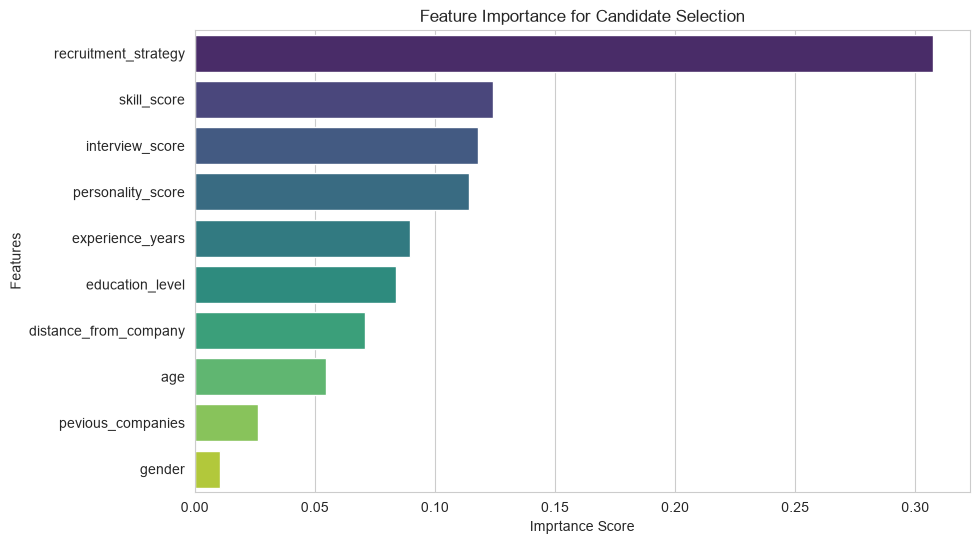

In [183]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature",
    palette="viridis"
)

plt.title("Feature Importance for Candidate Selection")
plt.xlabel("Imprtance Score")
plt.ylabel("Features")

plt.savefig(
    "../reports/feature_importance.png",
    bbox_inches="tight",
    dpi=300
)

In [184]:
best_pred = best_model.predict(x_test)

In [185]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    best_pred
)

cm

array([[203,   4],
       [ 13,  80]])

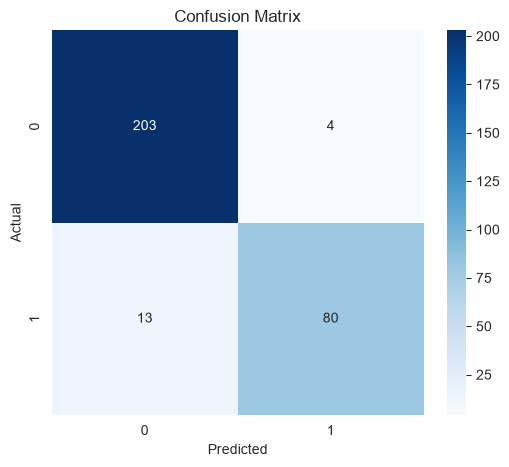

In [206]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../reports/confusion_matrix.png",
    bbox_inches="tight",
    dpi=300
)

In [187]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        best_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       207
           1       0.95      0.86      0.90        93

    accuracy                           0.94       300
   macro avg       0.95      0.92      0.93       300
weighted avg       0.94      0.94      0.94       300



In [194]:
from sklearn.metrics import roc_auc_score

# get probability predictin

if hasattr(best_model, "predict_proba"):


    best_probability = best_model.predict_proba(x_test)[:,1]
    auc_score = roc_auc_score(
        y_test,
        best_probability
    )

    print("ROC-AUC Score : ", auc_score*100)

else:
    print("ROC-AUC not available for this model")

ROC-AUC Score :  93.3977455716586


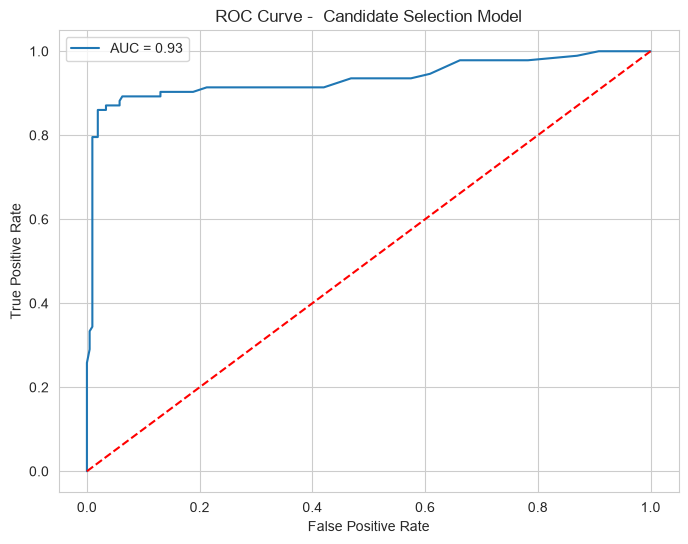

In [189]:
from sklearn.metrics import roc_curve

fpr, tpr, threshold = roc_curve(
    y_test,
    best_probability
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label = f"AUC = {auc_score:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle = "--",
    color = "red"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve -  Candidate Selection Model")

plt.legend()

plt.savefig(
    "../reports/roc_auc_curve.png",
    bbox_inches="tight",
    dpi=300
)

In [190]:
# best_model = rf_model

# model_dictionary = {
#     "Logistic Regression": lr_model,
#     "Decision Tree": dt_model,
#     "Random Forest": rf_model,
#     "XGBoost": xgb_model
# }

# best_model = model_dictionary[best_model_name]

In [191]:
import joblib

joblib.dump(
    best_model,
    "../models/best_model.joblib"
)

print("best Model Saved")

best Model Saved


In [192]:
joblib.dump(
    scaler,
    "../models/scaler.joblib"
)

print("sacler saved")

sacler saved


In [193]:
joblib.dump(
    encoders,
    "../models/encoder.joblib"
)

print("encoder saved")

encoder saved


In [195]:
joblib.dump(
    target_encoder,
    "../models/target_encoder.joblib"
)

print("Target encoder saved")

Target encoder saved


In [199]:
df.recruitment_strategy.unique()

<ArrowStringArray>
['Aggressive', 'Moderate', 'Constructive']
Length: 3, dtype: str

In [200]:
new_candidate = pd.DataFrame({
    "age":[25],
    "gender":["Male"],
    "education_level":["Master's"],
    "experience_years":[3],
    "pevious_companies":[2],
    "distance_from_company":[5],
    "interview_score":[85],
    "skill_score":[90],
    "personality_score":[80],
    "recruitment_strategy":["Constructive"]
})

new_candidate_encoded = new_candidate.copy()

In [201]:
for col in categorical_features:
    new_candidate_encoded[col] = encoders[col].transform(
        new_candidate_encoded[col]
    )

In [202]:
new_candidate_scaled = scaler.transform(
    new_candidate_encoded
)

In [203]:
predction = best_model.predict(
    new_candidate_scaled
)

c:\Users\pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [204]:
final_prediction = target_encoder.inverse_transform(
    predction
)

In [205]:
print("Prediction : ", final_prediction[0])

Prediction :  Not Selected
